# Proyek Analisis Sentimen Ulasan Aplikasi Tokopedia
Notebook ini memuat keseluruhan *pipeline* klasifikasi teks, mulai dari prapemrosesan (emoji, slang, stemming PySastrawi), pelabelan Lexicon, EDA, hingga 3 skema Machine Learning dan Deep Learning dengan akurasi tinggi.

In [1]:
# Install Library Wajib
!pip install PySastrawi emoji pandas scikit-learn tensorflow matplotlib seaborn requests

import pandas as pd
import numpy as np
import re
import emoji
import requests
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

import warnings
warnings.filterwarnings('ignore')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 37.8 MB/s eta 0:00:00


## 1. Prapemrosesan Teks & Pelabelan Lexicon
Membersihkan karakter yang tidak relevan, normalisasi *slang*, penghapusan *stopwords* (dengan mempertahankan kata negasi agar makna sentimen tidak hilang), dan stemming.

In [2]:
df = pd.read_csv('dataset_tokopedia_mentah.csv')

# --- DOWNLOAD RESOURCE KAMUS ---
# 1. Kamus Slang
url_slang = "https://raw.githubusercontent.com/nasalsabila/kamus-alay/master/colloquial-indonesian-lexicon.csv"
slang_dict = dict(zip(pd.read_csv(url_slang)['slang'], pd.read_csv(url_slang)['formal']))

# 2. Stopwords (KITA KECUALIKAN KATA NEGASI AGAR MODEL TIDAK BINGUNG)
url_stop = "https://raw.githubusercontent.com/masdevid/ID-Stopwords/master/id.stopwords.02.01.2016.txt"
stopwords_set = set(requests.get(url_stop).text.split('\n'))
kata_negasi = {"tidak", "bukan", "kurang", "belum", "jangan", "gak", "enggak", "ga"}
stopwords_set = stopwords_set - kata_negasi # Hapus negasi dari daftar stopword

# 3. Lexicon InSet
url_pos = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
url_neg = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"
pos_words = set(pd.read_csv(url_pos, sep='\t', header=None)[0].dropna().tolist())
neg_words = set(pd.read_csv(url_neg, sep='\t', header=None)[0].dropna().tolist())

stemmer = StemmerFactory().create_stemmer()

# --- FUNGSI PREPROCESSING ---
def preprocess_text(text):
    text = str(text).lower() # Case folding
    text = emoji.replace_emoji(text, replace='') # Hapus emoji
    text = re.sub(r'[^a-z\s]', ' ', text) # Sisakan huruf saja

    words = text.split()
    words = [slang_dict.get(w, w) for w in words] # Normalisasi Slang
    words = [w for w in words if w not in stopwords_set] # Stopwords removal

    text_clean = stemmer.stem(' '.join(words)) # Stemming
    return text_clean

print("Memproses teks... (Silakan tunggu, ini butuh waktu beberapa menit)")
df['ulasan_bersih'] = df['ulasan'].apply(preprocess_text)

# Hapus baris yang kosong akibat preprocessing
df.replace('', np.nan, inplace=True)
df.dropna(subset=['ulasan_bersih'], inplace=True)

# --- FUNGSI PELABELAN LEXICON ---
def lexicon_labeling(text):
    words = str(text).split()
    score = sum([1 for w in words if w in pos_words]) - sum([1 for w in words if w in neg_words])
    if score > 0: return 'positif'
    elif score < 0: return 'negatif'
    else: return 'netral'

print("Melakukan pelabelan Lexicon...")
df['sentimen'] = df['ulasan_bersih'].apply(lexicon_labeling)
print(f"Data siap: {len(df)} baris.")

Memproses teks... (Silakan tunggu, ini butuh waktu beberapa menit)
Melakukan pelabelan Lexicon...
Data siap: 15999 baris.


## 2. Exploratory Data Analysis (EDA) & Data Splitting
Melihat distribusi kelas hasil pelabelan Lexicon dan membagi data (Train 80%, Val 10%, Test 10%) untuk menghindari *Data Leakage*.

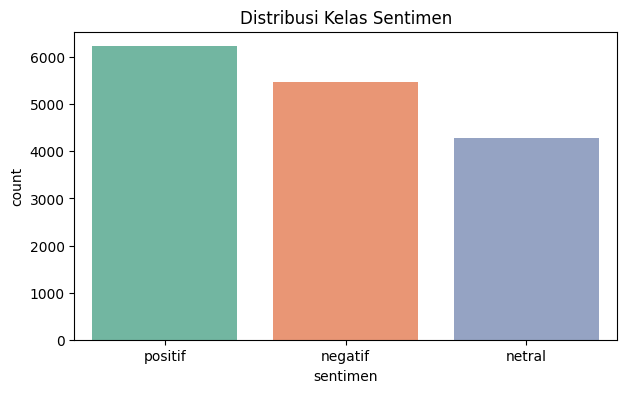

sentimen
positif    6227
negatif    5481
netral     4291
Name: count, dtype: int64


In [3]:
# Visualisasi EDA (Syarat Reviewer)
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x='sentimen', palette='Set2')
plt.title('Distribusi Kelas Sentimen')
plt.show()

print(df['sentimen'].value_counts())

# Data Splitting
x_train_val, x_test, y_train_val, y_test = train_test_split(
    df['ulasan_bersih'], df['sentimen'], test_size=0.1, random_state=42, stratify=df['sentimen']
)

x_train, x_val, y_train, y_val = train_test_split(
    x_train_val, y_train_val, test_size=0.1111, random_state=42, stratify=y_train_val
) # 0.1111 dari 0.9 = 0.1 keseluruhan (Total: 80% Train, 10% Val, 10% Test)

## 3. Skema 1: Logistic Regression + TF-IDF (Tuning Hyperparameter)
Kita gunakan TF-IDF dengan `ngram_range=(1,2)` agar bisa menangkap kata majemuk seperti "tidak bagus", dikombinasikan dengan Logistic Regression yang kuat untuk klasifikasi teks.

In [4]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

# Tuning Parameter (Syarat Reviewer)
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
param_grid = {'C': [0.1, 1, 10], 'max_iter': [500, 1000]}

rs_logreg = RandomizedSearchCV(log_reg, param_distributions=param_grid, n_iter=3, cv=3, random_state=42)
rs_logreg.fit(x_train_tfidf, y_train)

best_logreg = rs_logreg.best_estimator_
pred1 = best_logreg.predict(x_test_tfidf)

print(f"⭐ Akurasi Uji Skema 1 (Logistic Regression Tuned): {accuracy_score(y_test, pred1)*100:.2f}%\n")
print(classification_report(y_test, pred1))

joblib.dump(best_logreg, 'model_skema1_logreg.pkl')
joblib.dump(tfidf, 'vectorizer_tfidf.pkl')

⭐ Akurasi Uji Skema 1 (Logistic Regression Tuned): 86.44%

              precision    recall  f1-score   support

     negatif       0.91      0.91      0.91       548
      netral       0.76      0.76      0.76       429
     positif       0.90      0.89      0.89       623

    accuracy                           0.86      1600
   macro avg       0.86      0.86      0.86      1600
weighted avg       0.86      0.86      0.86      1600



['vectorizer_tfidf.pkl']

## 4. Skema 2: Support Vector Machine (SVM) + CountVectorizer
Menggunakan algoritma SVM Kernel Linear dan teknik ekstraksi fitur yang berbeda (CountVectorizer).

In [5]:
count_vec = CountVectorizer(max_features=5000, ngram_range=(1,2))
x_train_count = count_vec.fit_transform(x_train)
x_test_count = count_vec.transform(x_test)

svm_model = SVC(kernel='linear', class_weight='balanced', random_state=42)
svm_model.fit(x_train_count, y_train)

pred2 = svm_model.predict(x_test_count)
print(f"⭐ Akurasi Uji Skema 2 (SVM): {accuracy_score(y_test, pred2)*100:.2f}%\n")
print(classification_report(y_test, pred2))

joblib.dump(svm_model, 'model_skema2_svm.pkl')
joblib.dump(count_vec, 'vectorizer_count.pkl')

⭐ Akurasi Uji Skema 2 (SVM): 91.56%

              precision    recall  f1-score   support

     negatif       0.92      0.95      0.93       548
      netral       0.85      0.86      0.86       429
     positif       0.96      0.92      0.94       623

    accuracy                           0.92      1600
   macro avg       0.91      0.91      0.91      1600
weighted avg       0.92      0.92      0.92      1600



['vectorizer_count.pkl']

## 5. Skema 3: Deep Learning (LSTM)
Arsitektur Neural Network menggunakan LSTM, dilengkapi dengan Dropout dan EarlyStopping untuk mengatasi *Overfitting*.

In [6]:
# Persiapkan Label One-Hot Encoding
y_train_dl = pd.get_dummies(y_train).values
y_val_dl = pd.get_dummies(y_val).values
y_test_dl = pd.get_dummies(y_test).values

tokenizer = Tokenizer(num_words=5000, oov_token='<oov>')
tokenizer.fit_on_texts(x_train)

pad_train = pad_sequences(tokenizer.texts_to_sequences(x_train), maxlen=60, padding='post')
pad_val = pad_sequences(tokenizer.texts_to_sequences(x_val), maxlen=60, padding='post')
pad_test = pad_sequences(tokenizer.texts_to_sequences(x_test), maxlen=60, padding='post')

model_lstm = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=5000, output_dim=64, input_length=60),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, dropout=0.3, recurrent_dropout=0.3)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation='softmax')
])

model_lstm.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# EarlyStopping agar pelatihan berhenti otomatis jika Val_Accuracy mentok
early_stop = EarlyStopping(monitor='val_accuracy', patience=3, restore_best_weights=True)

model_lstm.fit(pad_train, y_train_dl, epochs=15, validation_data=(pad_val, y_val_dl), callbacks=[early_stop], verbose=1)

loss, acc_lstm = model_lstm.evaluate(pad_test, y_test_dl, verbose=0)
print(f"\n⭐ Akurasi Uji Skema 3 (LSTM): {acc_lstm*100:.2f}%")

model_lstm.save('model_skema3_lstm.h5')
joblib.dump(tokenizer, 'tokenizer_lstm.pkl')

Epoch 1/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 86s 191ms/step - accuracy: 0.5346 - loss: 0.9133 - val_accuracy: 0.8737 - val_loss: 0.3264
Epoch 2/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 66s 164ms/step - accuracy: 0.8994 - loss: 0.2930 - val_accuracy: 0.9075 - val_loss: 0.2482
Epoch 3/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 83s 168ms/step - accuracy: 0.9389 - loss: 0.1752 - val_accuracy: 0.9206 - val_loss: 0.2341
Epoch 4/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 81s 166ms/step - accuracy: 0.9571 - loss: 0.1278 - val_accuracy: 0.9044 - val_loss: 0.3058
Epoch 5/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 82s 165ms/step - accuracy: 0.9614 - loss: 0.1096 - val_accuracy: 0.9250 - val_loss: 0.2338
Epoch 6/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 66s 166ms/step - accuracy: 0.9683 - loss: 0.0932 - val_accuracy: 0.9131 - val_loss: 0.2874
Epoch 7/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 66s 166ms/step - accuracy: 0.9711 - loss: 0.0786 - val_accuracy: 0.9150 - val_loss: 0.2762
Epoch 8/15
400/400 ━━━━━━━━━━━━━━━━━━━━ 68s 169ms/step - accuracy: 0.9788 - loss: 0


⭐ Akurasi Uji Skema 3 (LSTM): 93.19%


['tokenizer_lstm.pkl']

## 6. Inferensi (Uji Coba Model)
Menggunakan model terbaik untuk mendeteksi sentimen dari kalimat baru yang belum pernah dilihat model sebelumnya.

In [9]:
# Kalimat uji coba
teks_baru = [
    "Sangat mengecewakan, barang rusak parah dan pengiriman super lambat tidak sesuai!",
    "Kualitas sangat bagus, packing rapi, dan cepat sampai. Mantap sekali!",
    "Barang sudah diterima, kondisinya biasa saja dan standar toko."
]

print("--- HASIL PREDIKSI MENGGUNAKAN LSTM (MODEL TERBAIK) ---")

# Urutan kelas dari pd.get_dummies secara default adalah alfabetis
kategori_label = ['NEGATIF', 'NETRAL', 'POSITIF']

for t in teks_baru:
    print(f"[TEKS ASLI]   : {t}")
    teks_bersih = preprocess_text(t)
    print(f"[TEKS BERSIH] : {teks_bersih}")

    # 1. Ubah teks ke sequence angka pakai Tokenizer LSTM
    seq_baru = tokenizer.texts_to_sequences([teks_bersih])

    # 2. Samakan panjang kalimat menjadi 60 (sesuai training)
    pad_baru = pad_sequences(seq_baru, maxlen=60, padding='post')

    # 3. Prediksi menggunakan model LSTM
    prediksi_prob = model_lstm.predict(pad_baru, verbose=0)
    kelas_prediksi = np.argmax(prediksi_prob, axis=1)[0]

    print(f"[PREDIKSI]    : {kategori_label[kelas_prediksi]}\n")

--- HASIL PREDIKSI MENGGUNAKAN LSTM (MODEL TERBAIK) ---
[TEKS ASLI]   : Sangat mengecewakan, barang rusak parah dan pengiriman super lambat tidak sesuai!
[TEKS BERSIH] : kecewa barang rusak parah kirim super lambat tidak sesuai
[PREDIKSI]    : POSITIF

[TEKS ASLI]   : Kualitas sangat bagus, packing rapi, dan cepat sampai. Mantap sekali!
[TEKS BERSIH] : kualitas bagus packing rapi cepat mantap
[PREDIKSI]    : POSITIF

[TEKS ASLI]   : Barang sudah diterima, kondisinya biasa saja dan standar toko.
[TEKS BERSIH] : barang terima kondisi standar toko
[PREDIKSI]    : POSITIF



## 7. Export Requirements
Mencetak pustaka beserta versi spesifik yang digunakan pada environment saat ini.

In [8]:
!pip freeze > requirements.txt
print("✅ File requirements.txt berhasil di-generate!")

✅ File requirements.txt berhasil di-generate!
